### Call and prepare categorielle data

Numériques : ['age', 'bmi', 'children', 'charges']
Catégorielles : ['sex', 'smoker', 'region']

=== Performances ===
Linear → RMSE:  4303.76 | R²: 0.8992
Ridge  → RMSE:  4302.87 | R²: 0.8992
Lasso  → RMSE:  4303.51 | R²: 0.8992

=== Top 15 features ===
                                           Linear        Ridge        Lasso
Feature                                                                    
smoker_yes                            5478.247440  5469.449851  5477.837806
smoker_yes_x_bmi_category_bmi_obese1  4100.988115  4094.558850  4100.861065
age_group_age_senior                  4033.879984  4017.099203  4033.363705
smoker_yes_x_bmi_category_bmi_obese2  3911.626074  3904.721604  3911.506335
smoker_yes_x_bmi_category_bmi_obese3  2843.494113  2836.240197  2843.265547
age_group_age_middle                  1890.773363  1880.402630  1890.394184
bmi_category_bmi_obese1               1356.149643  1250.009463  1344.164742
bmi_category_bmi_overweight           1339.907251  1231.767584 

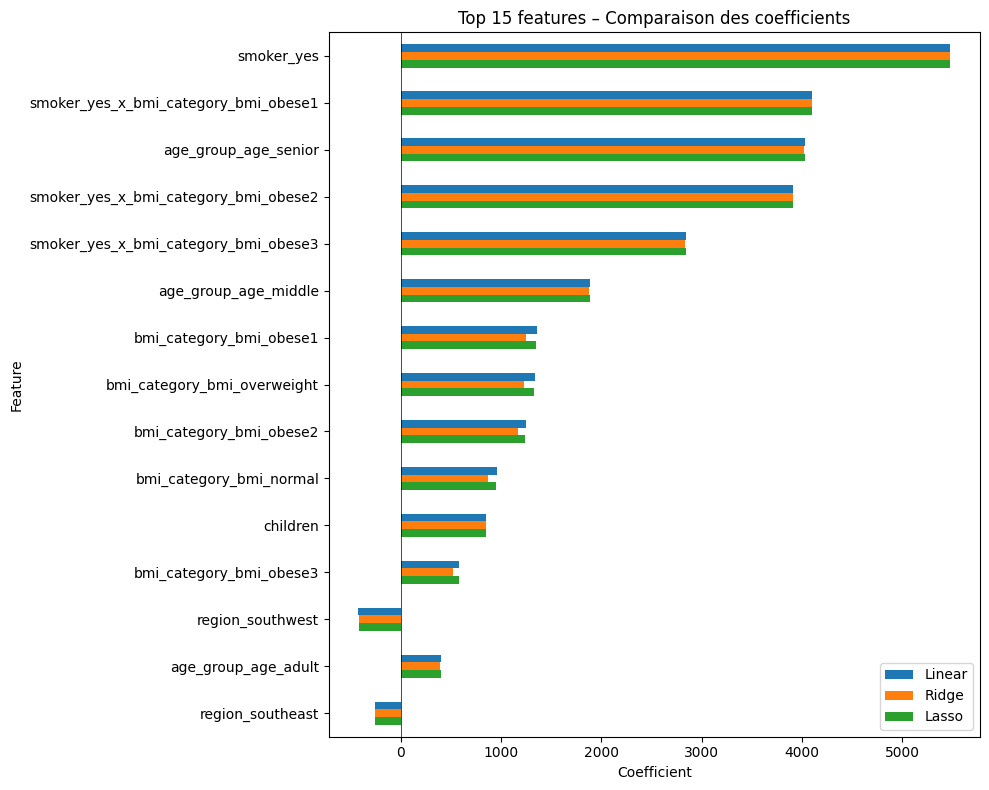

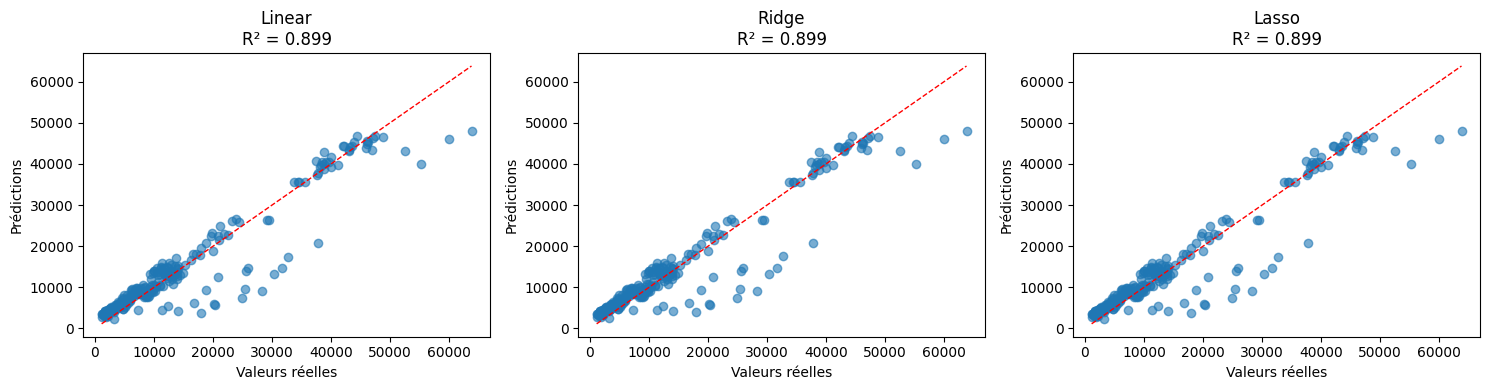

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# 1. Charger les données

df = pd.read_csv('../data/insurance.csv')
df = df.drop_duplicates()


# 2. Identifier types initiaux

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Numériques :", numerical_features)
print("Catégorielles :", categorical_features)


# 3. Créer catégories


# BMI category OMS
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 35, 40, 100],
    labels=['bmi_underweight', 'bmi_normal', 'bmi_overweight', 
            'bmi_obese1', 'bmi_obese2', 'bmi_obese3']
)

# Age category groupes
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['age_young', 'age_adult', 'age_middle', 'age_senior']
)


# 4. Supprimer les continues remplacées

df = df.drop(columns=['age', 'bmi'])


# 5. Encodage One-Hot

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region', 'bmi_category', 'age_group'], drop_first=True)


# 6. Interactions multiples (après encodage !)

# Fumeur × Obésité (tous niveaux)
for col in df_encoded.columns:
    if col.startswith('bmi_category_bmi_obese'):
        df_encoded[f'smoker_yes_x_{col}'] = df_encoded['smoker_yes'] * df_encoded[col]

# Fumeur × Âge senior
if 'age_group_age_senior' in df_encoded.columns:
    df_encoded['smoker_yes_x_age_senior'] = df_encoded['smoker_yes'] * df_encoded['age_group_age_senior']


# 7. Préparer X, y

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']


# 8. Standardisation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


# 9. Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# 10. Entraînement

alphas = np.logspace(-4, 4, 50)

lr = LinearRegression().fit(X_train, y_train)
ridge = RidgeCV(alphas=alphas, cv=5).fit(X_train, y_train)
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000).fit(X_train, y_train)


# 11. Évaluation

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

results_metric = {}

models = {'Linear': lr, 'Ridge': ridge, 'Lasso': lasso}
print("\n=== Performances ===")
print(f"{'Model'}")
for name, model in models.items():
    y_pred = model.predict(X_test)
    results_metric[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': rmse(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    }


# 12. Visualisation coefficients (top 15)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}).set_index('Feature')

coef_df = coef_df.reindex(coef_df['Linear'].abs().sort_values(ascending=False).index)

print("\n=== Top 15 features ===")
print(coef_df.head(15))

ax = coef_df.head(15).plot(kind='barh', figsize=(10, 8))
ax.set_xlabel('Coefficient')
ax.set_title('Top 15 features – Comparaison des coefficients')
ax.axvline(0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 13. Prédiction vs Réalité

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
    ax.set_xlabel('Valeurs réelles')
    ax.set_ylabel('Prédictions')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, y_pred):.3f}')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Charger les données et suppression du doublon
df = pd.read_csv('../data/insurance.csv')
df = df.drop_duplicates().reset_index(drop=True)

# 2. Gestion d'erreur hypothétique de la non présence du csv
if df.isnull().sum().any():
    print("Valeurs manquantes détectées.")
else:
    print("Aucune valeur manquante.")

# 3. Encoder sex et smoker en bool
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# 4. Créer catégories 
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 35, 40, 100],
    labels=['underweight', 'normal', 'overweight', 'obese1', 'obese2', 'obese3']
)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['young', 'adult', 'middle', 'senior']
)

# 5. Préparer un DataFrame pour le modèle 
df_for_model = df.drop(columns=['age', 'bmi'])

# 6. Encodage one-hot des catégories 
df_encoded = pd.get_dummies(
    df_for_model,
    columns=['region', 'bmi_category', 'age_group'],
    drop_first=True
)

# 7. Ajouter des interactions simples
# Interaction numérique : smoker × bmi
df_encoded['smoker_x_bmi'] = df['smoker'] * df['bmi']

# Interaction binaire : smoker × obésité (BMI ≥ 30)
df_encoded['smoker_x_obese'] = df['smoker'] * (df['bmi'] >= 30).astype(int)

# 8. Préparer X, y
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 9. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# 10. Split avec seed fixe
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 11. Entraînement
lr = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=1.0, max_iter=10000).fit(X_train, y_train)

# 12. Évaluation
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models = {'Linear': lr, 'Ridge': ridge, 'Lasso': lasso}
print("\n=== Performances ===")
print(f"{'Modèle':<8} | {'RMSE':>8} | {'MAE':>8} | {'R²':>8}")
for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse_val = rmse(y_test, y_pred)
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)
    print(f"{name:<8} | {rmse_val:8.2f} | {mae_val:8.2f} | {r2_val:8.4f}")

# 13. Analyse des erreurs fortes (sur le modèle linéaire)
y_pred_lr = lr.predict(X_test)
abs_errors = np.abs(y_test - y_pred_lr)

# Récupérer les vraies features (age, bmi, etc.) pour interpréter les erreurs
test_indices = X_test.index
df_errors = df.loc[test_indices].copy()
df_errors['y_true'] = y_test.values
df_errors['y_pred'] = y_pred_lr
df_errors['abs_error'] = abs_errors.values

# Top 5 erreurs absolues
print("\n=== TOP 5 ERREURS ABSOLUES ===")
top5 = df_errors.nlargest(5, 'abs_error')
print(top5[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'y_pred', 'abs_error']].to_string(index=False))

# 14. Visualisations avec Plotly

# a) Erreurs par interaction fumeur × obésité
df_errors['obese'] = (df_errors['bmi'] >= 30).astype(int)
df_errors['smoker_obese'] = df_errors['smoker'].map({0: 'Non-fumeur', 1: 'Fumeur'}) + ' × ' + \
                           df_errors['obese'].map({0: 'Non obèse', 1: 'Obèse'})

fig1 = px.box(
    df_errors,
    x='smoker_obese',
    y='abs_error',
    title="Erreurs absolues par interaction Fumeur × Obésité",
    labels={'smoker_obese': 'Segment', 'abs_error': 'Erreur absolue'}
)
fig1.update_xaxes(tickangle=15)
fig1.show()

# b) Erreur vs charges réelles (taille = BMI, couleur = fumeur)
fig2 = px.scatter(
    df_errors,
    x='y_true',
    y='abs_error',
    color=df_errors['smoker'].map({0: 'Non-fumeur', 1: 'Fumeur'}),
    size='bmi',
    hover_data=['age', 'bmi', 'children', 'region'],
    title="Erreur absolue vs Charges réelles"
)
fig2.update_layout(xaxis_title="Charges réelles", yaxis_title="Erreur absolue")
fig2.show()

# c) Prédiction vs Réalité
fig3 = px.scatter()
for name, model in models.items():
    y_pred = model.predict(X_test)
    fig3.add_scatter(x=y_test, y=y_pred, mode='markers', name=name, opacity=0.6)

fig3.add_scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    line=dict(color='red', dash='dash'),
    name='Perfect fit'
)
fig3.update_layout(
    title="Prédiction vs Réalité",
    xaxis_title="Valeurs réelles",
    yaxis_title="Prédictions"
)
fig3.show()

Aucune valeur manquante.

=== Performances ===
Modèle   |     RMSE |      MAE |       R²
Linear   |  4272.80 |  2472.62 |   0.9006
Ridge    |  4272.52 |  2475.35 |   0.9007
Lasso    |  4271.91 |  2471.94 |   0.9007

=== TOP 5 ERREURS ABSOLUES ===
 age  sex    bmi  children  smoker    region     charges       y_pred    abs_error
  45    0 27.645         1       0 northwest 28340.18885  8979.609977 19360.578873
  32    0 17.765         2       1 northwest 32734.18630 14486.222510 18247.963790
  60    1 28.595         0       0 northeast 30259.99556 12820.730331 17439.265229
  35    0 38.095         2       0 northeast 24915.04626  7591.496245 17323.550015
  62    0 36.860         1       0 northeast 31620.00106 14858.026463 16761.974597
